← [Transfer learning y MobileNet](07-transfer-learning-y-mobilenet.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Las otras dos señales](09-las-otras-dos-senales.ipynb) →

# 08 · Cambio de dominio

Este es el documento más importante de la serie. Explica por qué un modelo con
98,43 % de exactitud resultó ser mucho peor de lo que ese número sugería.



## Estado vigente del proyecto (actualizado el 13 de agosto de 2026)

Esta serie conserva explicaciones y resultados históricos, pero la referencia
operativa actual es la siguiente:

- El sistema experto tiene **193 reglas**, CF estilo MYCIN, meta-reglas,
  encadenamiento hacia adelante y hacia atrás. Su voto usa OpenAI como
  proveedor principal, con heurísticas OpenCV que refinan atributos.
- El modelo local que participa en la decisión es **MobileNetV2 TFLite
  float32**, corrida `run_20260721_2129`; clasifica solo `plastico | vidrio`.
  MobileNetV3-Large INT8 está archivado como respaldo y **no emite votos**.
- En 1.000 capturas OV3660/QVGA, V2 obtuvo **71,60 %** de exactitud y
  **71,25 %** de macro-F1; V3 INT8 obtuvo 57,10 % y 57,09 %. La validación
  histórica de 98,43 % no describe por sí sola el rendimiento del robot.
- La ESP32-CAM toma tres fotos: se suman los seis votos válidos de ambas
  fuentes. `desconocido` es abstención; un empate se resuelve con el proveedor.
  Si el proveedor se abstiene las tres veces, el modelo local necesita 3/3.

La documentación operativa es [`ia/vision-service/README.md`](../../ia/vision-service/README.md),
[`model/README.md`](../../ia/vision-service/model/README.md) y
[`PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md`](../../docs/PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md).


## El mismo modelo, tres notas distintas

| Escenario | Exactitud |
| --- | ---: |
| Validación del dataset propio | **98,43 %** |
| 1.000 capturas reales de la ESP32-CAM | **71,60 %** |
| 68 capturas de webcam 720p | **63,2 %** |

Es el **mismo archivo `model.tflite`** en los tres casos. No se reentrenó nada
entre una medición y otra.

La analogía que se usó en el proyecto: 98,43 % es la nota de un examen con las
mismas preguntas que se practicaron. Los otros dos son exámenes sorpresa con
preguntas nuevas.



## Qué es el cambio de dominio

Un modelo aprende de un conjunto de fotos con características propias: esa
cámara, esa luz, esos fondos, esa resolución. Ese conjunto es su **dominio**.

Cuando se le pide trabajar sobre fotos de otro dominio, su rendimiento cae —
aunque el problema conceptual sea idéntico. Botellas siguen siendo botellas;
lo que cambió es cómo se ven.

Entre el dataset de entrenamiento y la ESP32-CAM con OV3660 cambiaron:

- la cámara y su óptica;
- la resolución (QVGA, 320 × 240);
- la compresión JPEG;
- la iluminación y los fondos reales;
- los encuadres, a veces parciales o rotados;
- la variedad de objetos físicos, mucho menor.


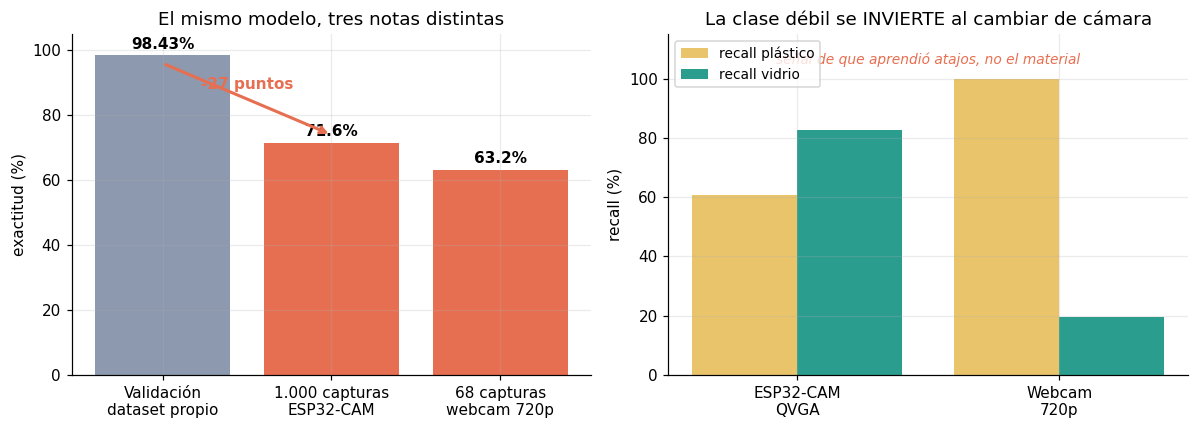

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# El mismo model.tflite medido en tres dominios distintos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

escenarios = ["Validación\ndataset propio", "1.000 capturas\nESP32-CAM", "68 capturas\nwebcam 720p"]
valores = [98.43, 71.60, 63.2]
barras = ax1.bar(escenarios, valores, color=[GRIS, ALERTA, ALERTA])
ax1.set(ylabel="exactitud (%)", ylim=(0, 105),
        title="El mismo modelo, tres notas distintas")
for b, v in zip(barras, valores):
    ax1.text(b.get_x() + b.get_width()/2, v + 2, f"{v}%", ha="center", weight="bold")
ax1.annotate("", xy=(1, 74), xytext=(0, 96),
             arrowprops=dict(arrowstyle="->", color=ALERTA, lw=2))
ax1.text(0.5, 88, "-27 puntos", color=ALERTA, ha="center", weight="bold")

# La clase débil se invierte según la cámara: prueba de atajos
x = np.arange(2)
ax2.bar(x - 0.2, [60.60, 100.0], 0.4, label="recall plástico", color=PLASTICO)
ax2.bar(x + 0.2, [82.60, 19.4], 0.4, label="recall vidrio", color=VIDRIO)
ax2.set_xticks(x); ax2.set_xticklabels(["ESP32-CAM\nQVGA", "Webcam\n720p"])
ax2.set(ylabel="recall (%)", ylim=(0, 115),
        title="La clase débil se INVIERTE al cambiar de cámara")
ax2.legend(fontsize=9)
ax2.text(0.5, 105, "señal de que aprendió atajos, no el material",
         ha="center", fontsize=9, color=ALERTA, style="italic")

plt.tight_layout(); plt.show()

## Atajos: por qué ocurre

La causa de fondo es que **una red aprende lo que sea que separe las clases en
sus datos**, no necesariamente lo que uno cree que está enseñando.

Si en el dataset de entrenamiento las botellas de vidrio se fotografiaron sobre
una mesa oscura y las de plástico sobre una clara, la red puede aprender "fondo
oscuro = vidrio". Con esos datos acertaría el 98 %. Con la ESP32-CAM, donde el
fondo es otro, fallaría — y nadie habría sabido que aprendió eso.

Esos son los **atajos** (*shortcut learning*). Son invisibles mientras se mida
en el mismo dominio: por eso el 98,43 % no era mentira, era **irrelevante**.



## La prueba de que hubo atajos

Una tabla del `model/README.md` cierra el argumento:

| Evaluación | Recall plástico | Recall vidrio |
| --- | ---: | ---: |
| ESP32-CAM OV3660/QVGA (1.000 fotos) | 60,60 % | 82,60 % |
| Webcam 720p (68 fotos) | 100 % | 19,4 % |

**La clase débil se invierte según la cámara.** Con una, el modelo casi no
reconoce plástico; con otra, casi no reconoce vidrio.

Eso no es ruido estadístico ni mala suerte. Si el modelo hubiera aprendido qué
es el vidrio, fallaría de forma parecida en ambos casos. Que la debilidad
cambie de clase al cambiar de cámara demuestra que **lo aprendido depende del
dominio**, no del material.


## Peor aún: falla con confianza

De 25 errores de vidrio en la evaluación de webcam, **17 tenían confianza ≥
0,90** y dos exactamente `1.0000`.

La consecuencia práctica es dura: **no se pueden filtrar esos errores con un
umbral**. La receta habitual —"si la confianza es baja, abstenerse"— no sirve,
porque los errores no vienen con confianza baja.

Hay además una asimetría delatora: cuando el modelo dice "plástico" llega a
`1.000000`, pero cuando dice "vidrio" nunca pasó de 0,956. Ni siquiera está
igual de calibrado en las dos direcciones.

Y otro dato que quita la salida fácil: en 32 ráfagas de 3 fotos del mismo
objeto, 30 fueron unánimes. El modelo es **estable en el error** — tomar tres
fotos no lo rescata, porque falla las tres igual.



## Qué se hace al respecto

**1. Medir siempre en el dominio real.** Las métricas del dataset viejo no
predicen el comportamiento del robot. Nunca presentar 98,43 % como precisión
esperada.

**2. Reservar un conjunto de prueba que nunca se toque.** Ver
[11](11-como-se-mide.ipynb).

**3. Entrenar con fotos del dominio real.** Es lo más efectivo. Cuando se
reentrenó MobileNetV2 incluyendo capturas de la ESP32-CAM, pasó de 71,60 % a
**90,28 %** de macro-F1. Casi 19 puntos, sin cambiar de arquitectura.

**4. Simular el dominio con aumentos.** Los scripts de entrenamiento degradan
las fotos a QVGA y les aplican compresión JPEG aleatoria durante el
entrenamiento, para que el modelo vea algo parecido a lo que encontrará.

**5. No dejarlo decidir solo.** Mientras el modelo local no tenga validación
independiente suficiente, es un voto de respaldo, no la señal primaria.



## La lección general

> Una métrica alta solo significa algo si se midió sobre datos que se parecen a
> los que el sistema encontrará en producción.

El salto de 98,43 % a 71,60 % no fue un error de programación: el modelo estaba
correctamente portado y ejecutaba bien. Fue un error de **interpretación** de lo
que la métrica significaba.

---

← [Transfer learning y MobileNet](07-transfer-learning-y-mobilenet.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Las otras dos señales](09-las-otras-dos-senales.ipynb) →
